In [3]:
import os
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

HAND_CONNECTIONS = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (0, 5),
    (5, 6),
    (6, 7),
    (7, 8),
    (5, 9),
    (9, 10),
    (10, 11),
    (11, 12),
    (9, 13),
    (13, 14),
    (14, 15),
    (15, 16),
    (13, 17),
    (17, 18),
    (18, 19),
    (19, 20),
    (0, 17)
]

BASE_DIR = Path.cwd().parent
DATA_CSV = os.path.normpath(os.path.join(BASE_DIR, "data", "processed", "landmarks.csv"))

In [4]:
if not os.path.exists(DATA_CSV):
    print(f"Error: Dataset not found at {DATA_CSV}")
else:
    print("Loading dataset")
    df = pd.read_csv(DATA_CSV)

    examples_df = df.groupby("label_name").first().reset_index()

    num_classes = len(examples_df)
    print(f"Found {num_classes} gesture classes to visualize.")

Loading dataset
Found 23 gesture classes to visualize.


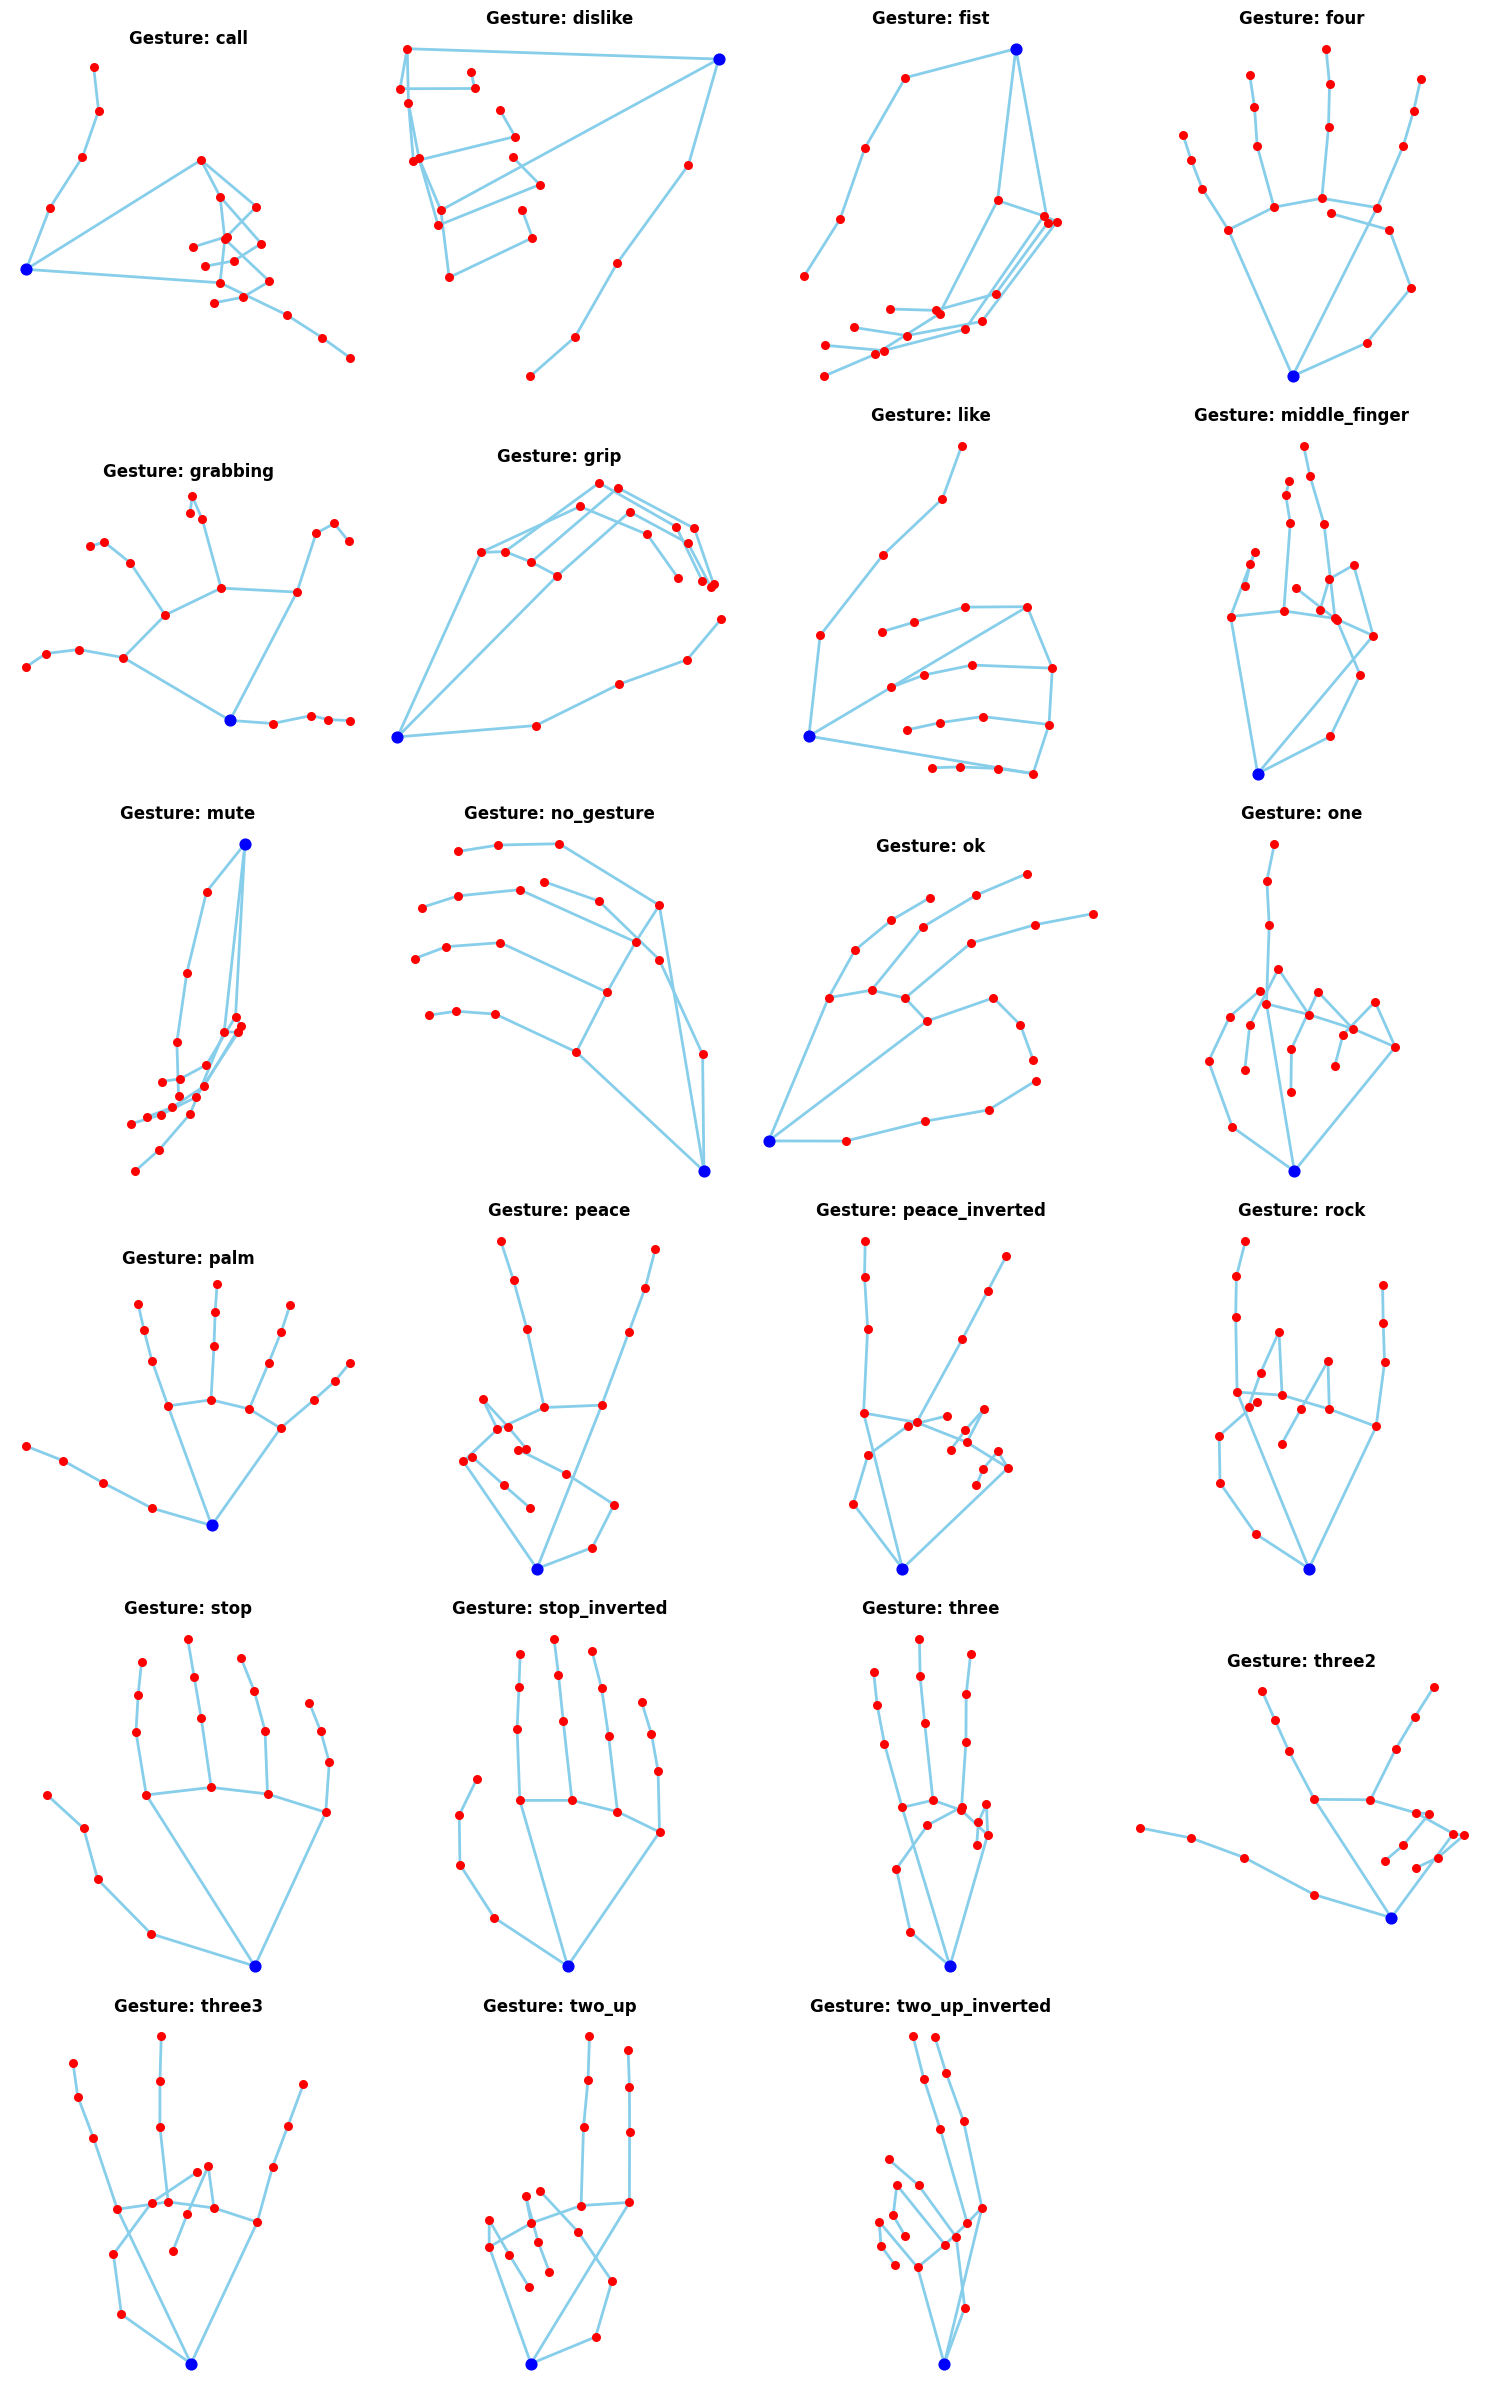

In [5]:
if 'examples_df' in locals():
    cols = 4
    rows = int(np.ceil(num_classes / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()

    for idx, row in examples_df.iterrows():
        ax = axes[idx]
        label_name = row["label_name"]

        coords = row[[f"coord_{i}" for i in range(42)]].values.astype(float)

        x_coords = coords[0::2]
        y_coords = coords[1::2]

        for connection in HAND_CONNECTIONS:
            start_idx, end_idx = connection
            ax.plot(
                [x_coords[start_idx], x_coords[end_idx]],
                [y_coords[start_idx], y_coords[end_idx]],
                color='skyblue', linewidth=2
            )

        ax.scatter(x_coords, y_coords, color='red', s=30, zorder=5)

        ax.scatter(x_coords[0], y_coords[0], color='blue', s=60, zorder=6, label='Wrist (Origin)')

        ax.set_title(f"Gesture: {label_name}", fontweight='bold')

        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.axis('off')

    for i in range(num_classes, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()